In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Building a Review-Based QA System

In [2]:
from datasets import get_dataset_config_names

domains = get_dataset_config_names("subjqa", trust_remote_code=True)
domains

README.md: 0.00B [00:00, ?B/s]

subjqa.py: 0.00B [00:00, ?B/s]

['books', 'electronics', 'grocery', 'movies', 'restaurants', 'tripadvisor']

In [3]:
from datasets import load_dataset

# Load dataset with explicit cache directory
subjqa = load_dataset(
    "subjqa", name="electronics"
)

data.zip:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1295 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/358 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/255 [00:00<?, ? examples/s]

In [4]:
print(subjqa["train"]["answers"][1])

{'text': ['Bass is weak as expected', 'Bass is weak as expected, even with EQ adjusted up'], 'answer_start': [1302, 1302], 'answer_subj_level': [1, 1], 'ans_subj_score': [0.5083333253860474, 0.5083333253860474], 'is_ans_subjective': [True, True]}


In [5]:
import pandas as pd

dfs = {split: dset.to_pandas() for split, dset in subjqa.flatten().items()}

for split, df in dfs.items():
    print(f"Number of questions in {split}: {df['id'].nunique()}")

Number of questions in train: 1295
Number of questions in test: 358
Number of questions in validation: 255


In [6]:
qa_cols = ["title", "question", "answers.text", "answers.answer_start", "context"]
sample_df = dfs["train"][qa_cols].sample(2, random_state=7)
sample_df

,title,question,answers.text,answers.answer_start,context
791,B005DKZTMG,Does the keyboard lightweight?,[this keyboard is compact],[215],I really like this keyboard. I give it 4 star...
1159,B00AAIPT76,How is the battery?,[],[],I bought this after the first spare gopro batt...


In [7]:
start_idx = sample_df["answers.answer_start"].iloc[0][0]
end_idx = start_idx + len(sample_df["answers.text"].iloc[0][0])
sample_df["context"].iloc[0][start_idx:end_idx]

'this keyboard is compact'

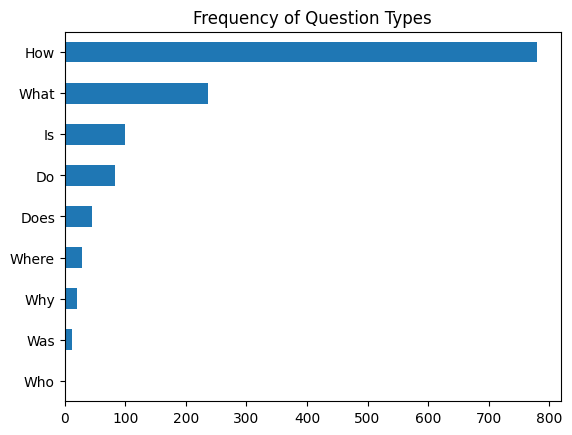

In [8]:
import matplotlib.pyplot as plt

counts = {}
question_types = ["What", "How", "Is", "Does", "Do", "Was", "Where", "Why", "Who"]

for q in question_types:
    counts[q] = dfs["train"]["question"].str.startswith(q).value_counts()[True]
pd.Series(counts).sort_values().plot.barh()
plt.title("Frequency of Question Types")
plt.show()

In [9]:
for question_type in ["How", "What", "Is"]:
    for question in dfs["train"][
        dfs["train"].question.str.startswith(question_type)
    ].sample(n=3, random_state=42)["question"]:
        print(question)

How is the camera?
How do you like the control?
How fast is the charger?
What is direction?
What is the quality of the construction of the bag?
What is your impression of the product?
Is this how zoom works?
Is sound clear?
Is it a wireless keyboard?


### Extracting Answers from Text

*Tokenizing text for QA*

In [10]:
from transformers import AutoTokenizer

model_ckpt = "deepset/minilm-uncased-squad2"
# Load tokenizer with explicit cache directory
tokenizer = AutoTokenizer.from_pretrained(
    model_ckpt
)

tokenizer_config.json:   0%|          | 0.00/107 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [11]:
question = "how much music can this hold?"
context = """
An Mp3 is about 1MB/minute, so about 6000 hours depending on \
    file size.
"""
inputs = tokenizer(question, context, return_tensors="pt")

In [12]:
print(tokenizer.decode(inputs["input_ids"][0]))

[CLS] how much music can this hold? [SEP] an mp3 is about 1mb / minute, so about 6000 hours depending on file size. [SEP]


In [13]:
import torch
from transformers import AutoModelForQuestionAnswering

# Load model with explicit cache directory
model = AutoModelForQuestionAnswering.from_pretrained(
    model_ckpt
)
with torch.no_grad():
    outputs = model(**inputs)
print(outputs)

2025-10-03 03:20:59.710341: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759461659.953509      54 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759461660.026859      54 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Some weights of the model checkpoint at deepset/minilm-uncased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


QuestionAnsweringModelOutput(loss=None, start_logits=tensor([[-1.1224, -4.7834, -5.3935, -5.2447, -5.2899, -5.4980, -4.9885, -6.1783,
         -1.1224,  0.3651, -0.0807, -1.5551,  3.9556,  4.9206, -2.7833, -3.7461,
         -1.7211, -4.6096, -1.3769,  4.0256,  4.9715, -0.2477, -3.0354, -4.8180,
         -2.2386, -3.4867, -3.5462, -1.1224]]), end_logits=tensor([[-1.0707, -5.4841, -5.0304, -5.1770, -5.4496, -5.5120, -5.2013, -4.6178,
         -1.0707, -3.7223, -0.7583, -3.6969, -2.9205, -1.7346,  0.3122, -2.8688,
          4.8807,  0.2692, -3.1317, -3.2404,  0.8239,  5.6645, -0.2568, -4.8910,
         -3.1677, -0.0130,  1.6739, -1.0707]]), hidden_states=None, attentions=None)


In [14]:
start_logits = outputs.start_logits
end_logits = outputs.end_logits

In [15]:
print(f"Input IDs shape: {inputs.input_ids.size()}")
print(f"Start logits shape: {start_logits.size()}")
print(f"End logits shape: {end_logits.size()}")

Input IDs shape: torch.Size([1, 28])
Start logits shape: torch.Size([1, 28])
End logits shape: torch.Size([1, 28])


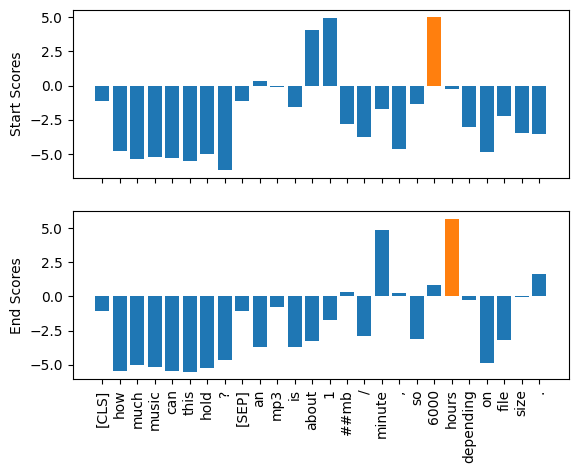

In [16]:
import numpy as np
import matplotlib.pyplot as plt

s_scores = start_logits.detach().numpy().flatten()
e_scores = end_logits.detach().numpy().flatten()
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True)
colors = ["C0" if s != np.max(s_scores) else "C1" for s in s_scores]
ax1.bar(x=tokens, height=s_scores, color=colors)
ax1.set_ylabel("Start Scores")
colors = ["C0" if s != np.max(e_scores) else "C1" for s in e_scores]
ax2.bar(x=tokens, height=e_scores, color=colors)
ax2.set_ylabel("End Scores")
plt.xticks(rotation="vertical")
plt.show()

In [17]:
import torch

start_idx = torch.argmax(start_logits)
end_idx = torch.argmax(end_logits) + 1
answer_span = inputs["input_ids"][0][start_idx:end_idx]
answer = tokenizer.decode(answer_span)
print(f"Question:{question}")
print(f"Answer:{answer}")

Question:how much music can this hold?
Answer:6000 hours


In [18]:
from transformers import pipeline

pipe = pipeline("question-answering", model=model, tokenizer=tokenizer)
pipe(question=question, context=context, topk=3)

Device set to use cpu
/usr/local/lib/python3.11/dist-packages/transformers/pipelines/question_answering.py:334: UserWarning: topk parameter is deprecated, use top_k instead
  warnings.warn("topk parameter is deprecated, use top_k instead", UserWarning)


[{'score': 0.2436027228832245, 'start': 38, 'end': 48, 'answer': '6000 hours'},
 {'score': 0.23150843381881714,
  'start': 17,
  'end': 48,
  'answer': '1MB/minute, so about 6000 hours'},
 {'score': 0.10571714490652084,
  'start': 17,
  'end': 27,
  'answer': '1MB/minute'}]

In [19]:
pipe(question="Why is there no data?", context=context, handle_impossible_answer=True)

{'score': 0.8946098685264587, 'start': 0, 'end': 0, 'answer': ''}

### Dealing with long passages

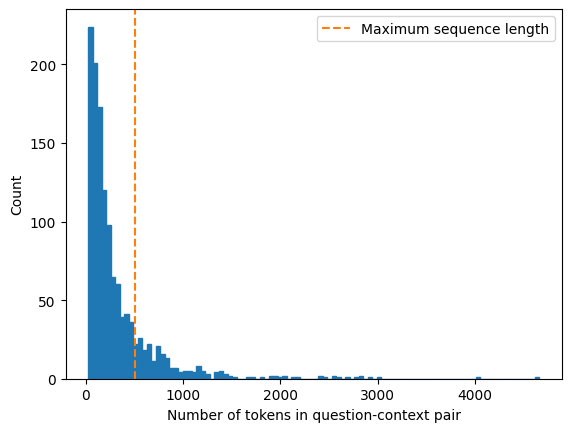

In [20]:
# caption Distribution of tokens for each question-context pair in the SubjQA training set
def compute_input_length(row):
    inputs = tokenizer(row["question"], row["context"])
    return len(inputs["input_ids"])


dfs["train"]["n_tokens"] = dfs["train"].apply(compute_input_length, axis=1)

fig, ax = plt.subplots()
dfs["train"]["n_tokens"].hist(bins=100, grid=False, ec="C0", ax=ax)
plt.xlabel("Number of tokens in question-context pair")
ax.axvline(
    x=512, ymin=0, ymax=1, linestyle="--", color="C1", label="Maximum sequence length"
)
plt.legend()
plt.ylabel("Count")
plt.show()

In [21]:
example = dfs["train"].iloc[0][["question", "context"]]
tokenized_example = tokenizer(
    example["question"],
    example["context"],
    return_overflowing_tokens=True,
    max_length=100,
    stride=25,
)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


In [22]:
for idx, window in enumerate(tokenized_example["input_ids"]):
    print(f"Window #{idx} has {len(window)} tokens")

Window #0 has 100 tokens
Window #1 has 88 tokens


In [23]:
for window in tokenized_example["input_ids"]:
    print(f"{tokenizer.decode(window)}\n")

[CLS] how is the bass? [SEP] i have had koss headphones in the past, pro 4aa and qz - 99. the koss portapro is portable and has great bass response. the work great with my android phone and can be " rolled up " to be carried in my motorcycle jacket or computer bag without getting crunched. they are very light and do not feel heavy or bear down on your ears even after listening to music with them on all day. the sound is [SEP]

[CLS] how is the bass? [SEP] and do not feel heavy or bear down on your ears even after listening to music with them on all day. the sound is night and day better than any ear - bud could be and are almost as good as the pro 4aa. they are " open air " headphones so you cannot match the bass to the sealed types, but it comes close. for $ 32, you cannot go wrong. [SEP]



### Using Haystack to Build a QA Pipeline

*Initializing a Document store*

In [ ]:
%pip uninstall -y farm-haystack haystack-ai
%pip install haystack-ai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 592.1/592.1 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.3/137.3 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 2.6 MB/s eta 0:00:00


In [25]:
from haystack.document_stores.in_memory import InMemoryDocumentStore

# Connect to your local ES instance
document_store = InMemoryDocumentStore(return_embedding=True, bm25_algorithm="BM25L")

In [26]:
if len(document_store.filter_documents()) > 0:
    document_store.delete_documents(index=document_store.index)
    print("Document store cleared ✅")

In [27]:
from haystack import Document

for split, df in dfs.items():
    # Exclude duplicate reviews
    docs = [
        Document(
            content=row["context"],
            meta={"item_id": row["title"], "question_id": row["id"], "split": split},
        )
        for _, row in df.drop_duplicates(subset="context").iterrows()
    ]
    document_store.write_documents(docs)

print(f"Loaded {document_store.count_documents()} documents")

Loaded 1875 documents


### Initializing a Retriever

In [28]:
from haystack.components.retrievers import InMemoryBM25Retriever

retriever = InMemoryBM25Retriever(document_store=document_store)

In [29]:
item_id = "B0074BW614"
query = "Is it good for reading?"
filters = {
    "operator": "AND",
    "conditions": [
        {"field": "item_id", "operator": "==", "value": item_id},
        {"field": "split", "operator": "==", "value": "train"},
    ],
}

retrieved_docs = retriever.run(query=query, filters=filters, top_k=3)
for docs in retrieved_docs["documents"]:
    print(docs.content, docs.meta)
    print("\n")

This is a gift to myself.  I have been a kindle user for 4 years and this is my third one.  I never thought I would want a fire for I mainly use it for book reading.  I decided to try the fire for when I travel I take my laptop, my phone and my iPod classic.  I love my iPod but watching movies on the plane with it can be challenging because it is so small. Laptops battery life is not as good as the Kindle.  So the Fire combines for me what I needed all three to do. So far so good. {'item_id': 'B0074BW614', 'question_id': '868e311275e26dbafe5af70774a300f3', 'split': 'train'}


Plays Netflix great, WiFi capability has great range. Resolution on the screen is AMAZING! For the price you cannot go wrong. Bought one for my spouse and myself after becoming addicted to hers! Our son LOVES it and it is great for reading books when no light is available. Amazing sound but I suggest good headphones to really hear it all.Battery life is super long and can go 3 or 4 days without a recharge from mod

### Initializing a Reader

In [30]:
from haystack.components.readers import ExtractiveReader

model_ckpt = "deepset/minilm-uncased-squad2"

reader = ExtractiveReader(model=model_ckpt)

In [31]:
reader.warm_up()
question = "What is the capital of France?"
context = "Paris is the capital and most populous city of France."
doc = Document(content=context)
results = reader.run(query=question, documents=[doc], top_k=1)
print(results)

Some weights of the model checkpoint at deepset/minilm-uncased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


{'answers': [ExtractedAnswer(query='What is the capital of France?', score=0.7686592936515808, data='Paris', document=Document(id=9f9564cf32e09dca1a34d7793ac4bc2813b57f1cc99b120422cd11a9351e064c, content: 'Paris is the capital and most populous city of France.'), context=None, document_offset=ExtractedAnswer.Span(start=0, end=5), context_offset=None, meta={}), ExtractedAnswer(query='What is the capital of France?', score=0.2313407063484192, data=None, document=None, context=None, document_offset=None, context_offset=None, meta={})]}


### Putting it all together

In [32]:
from haystack import Pipeline


pipe = Pipeline()

In [33]:
#pipe.remove_component(name="Retriever")
#pipe.remove_component(name="Reader")

In [34]:
# retriever and reader must be instantiated
pipe.add_component(name="Retriever", instance=retriever)
pipe.add_component(
    name="Reader",
    instance=reader,
)

In [36]:
pipe.connect("Retriever", "Reader")
preds = pipe.run(
    {"Retriever": {"query": query}, "Reader": {"query": query, "top_k": 3}}
)


print(preds)

{'Reader': {'answers': [ExtractedAnswer(query='Is it good for reading?', score=0.7773743867874146, data='They sound great', document=Document(id=7bf053580a1be7ebfb048413bd008c834b72cb3562af8b12e673a42dd68bb3f7, content: 'I bought these after reading the reviews of multiple In-Ear Headphones. The reviews were mostly posi...', meta: {'item_id': 'B003ELYQGG', 'question_id': '59b24d7e21fcc1c0c8c6081e505349be', 'split': 'train'}, score: 6.847688416351596), context=None, document_offset=ExtractedAnswer.Span(start=148, end=164), context_offset=None, meta={}), ExtractedAnswer(query='Is it good for reading?', score=0.775586724281311, data='This is a good tablet for reading books', document=Document(id=9a9a7e6f969ed160551da92db5ef48146504e6e7d11f0d714ef05c968d1b5bb9, content: 'I really haven't found anything to dislike about this. It's a considerable improvement over the prev...', meta: {'item_id': 'B00DVFLJDS', 'question_id': 'f9a7e7eb40501bf4a2bda84799f6fdd0', 'split': 'train'}, score: 6.94651

In [37]:
# Check the structure of the output
print("Pipeline output keys:", preds.keys())
print("Reader output keys:", preds["Reader"].keys())
print("Number of answers:", len(preds["Reader"]["answers"]))

Pipeline output keys: dict_keys(['Reader'])
Reader output keys: dict_keys(['answers'])
Number of answers: 4


In [38]:
# Access the results from the Reader component
results = preds["Reader"]["answers"]

for idx, answer in enumerate(results):
    print(f"Answer {idx+1}: {answer.data}")
    print(f"Review snippet: ...{answer.context}...")
    print(f"Score: {answer.score}")
    print("\n")

Answer 1: They sound great
Review snippet: ...None...
Score: 0.7773743867874146


Answer 2: This is a good tablet for reading books
Review snippet: ...None...
Score: 0.775586724281311


Answer 3: I mainly use it for book reading
Review snippet: ...None...
Score: 0.7750784158706665


Answer 4: None
Review snippet: ...None...
Score: 0.01123711453386021




## Improving Our QA Pipeline

### Evaluating the Retriever

In [39]:
from haystack import Pipeline
from haystack.components.retrievers import InMemoryBM25Retriever

new_retriever = InMemoryBM25Retriever(document_store=document_store)
class EvalRetrieverPipeline:
    def __init__(self, retriever):
        self.retriever = retriever
        pipe = Pipeline()
        pipe.add_component(instance=self.retriever, name="ESRetriever")
        self.pipeline = pipe


pipe = EvalRetrieverPipeline(new_retriever)

In [40]:
from haystack import *

print([name for name in dir() if "Label" in name or "Answer" in name])

['Answer', 'AutoModelForQuestionAnswering', 'ExtractedAnswer', 'GeneratedAnswer']


In [42]:
from haystack.dataclasses import Document

# For Haystack 2.x evaluation, you typically work with Documents and create
# a dataset structure for evaluation

labels = []
for i, row in dfs["test"].iterrows():
    # Metadata used for filtering in the Retriever
    meta = {"item_id": row["title"], "question_id": row["id"], "origin": row["id"]}

    # Populate eval data for questions with answers
    if len(row["answers.text"]):
        answers = list(row["answers.text"])
        labels.append(
            {
                "question": row["question"],
                "answers": answers,
                "meta": meta,
                "document_id": row["id"],
            }
        )
    # Populate eval data for questions without answers
    else:
        labels.append(
            {
                "question": row["question"],
                "answers": [],
                "meta": meta,
                "document_id": row["id"],
            }
        )

In [43]:
# Check the first few rows to see what's happening
for i, row in dfs["test"].head(10).iterrows():
    print(f"Row {i}:")
    print(f"  Question: {row['question']}")
    print(f"  Answers: {row['answers.text']}")
    print(f"  Has answers: {len(row['answers.text']) > 0}")
    print(f"  Type of answers.text: {type(row['answers.text'])}")
    print("---")

Row 0:
  Question: What is the tonal balance of these headphones?
  Answers: ['I have been a headphone fanatic for thirty years']
  Has answers: True
  Type of answers.text: <class 'numpy.ndarray'>
---
Row 1:
  Question: How would you describe the texture of the lens at all focal lengths above 150mm?
  Answers: []
  Has answers: False
  Type of answers.text: <class 'numpy.ndarray'>
---
Row 2:
  Question: How is the thing?
  Answers: []
  Has answers: False
  Type of answers.text: <class 'numpy.ndarray'>
---
Row 3:
  Question: How do you like the lens?
  Answers: ['I do recommend this lens']
  Has answers: True
  Type of answers.text: <class 'numpy.ndarray'>
---
Row 4:
  Question: How is the contrast?
  Answers: []
  Has answers: False
  Type of answers.text: <class 'numpy.ndarray'>
---
Row 5:
  Question: Is the cord safe to grab the transformer?
  Answers: ['The cord is very long and durable']
  Has answers: True
  Type of answers.text: <class 'numpy.ndarray'>
---
Row 6:
  Question: Ho

In [45]:
# Write labels to document store
document_store.write_documents(labels)
print(f"Loaded {len(document_store.filter_documents())} question-answer pairs")

ValueError: Please provide a list of Documents.

In [ ]:
# Alternative approach
labels_agg = document_store.filter_documents()
# Then group by item_id manually
import pandas as pd

df = pd.DataFrame([doc.meta for doc in labels_agg])
grouped = df.groupby("item_id")

In [ ]:
print(labels_agg[109])

Document(id=730576f1a1d91044dd966eda68abbf4c51af9fc14646c0daabddbc3202ef44ae, content: 'This Keyboard is very comfortable. My other Natural Ergonomics Keyboard burnt out after 5 and 1/2 ye...', meta: {'item_id': 'B000A6PPOK', 'question_id': 'ec6a531ab9f668574eaecc93e359e996', 'split': 'train'})


In [ ]:
def run_pipeline(pipeline, top_k_retriever=10, top_k_reader=4):
    for l in labels_agg:
        # Get query from document content or meta
        query = l.content if hasattr(l, "content") else l.meta.get("query", "")
        _ = pipeline.pipeline.run(
            {"ESRetriever": {"query": query, "top_k": top_k_retriever}}
        )

In [ ]:
run_pipeline(pipe, top_k_retriever=3)

# Manual evaluation if needed
print("Pipeline evaluation completed")

Pipeline evaluation completed


In [ ]:
from haystack import Pipeline
from haystack.components.retrievers import InMemoryBM25Retriever

class EvalRetrieverPipeline:
    def __init__(self, retriever):
        self.retriever = retriever
        pipe = Pipeline()
        pipe.add_component(instance=self.retriever, name="ESRetriever")
        self.pipeline = pipe
        # Add evaluation metrics
        self.recall = 0.0
        self.precision = 0.0
        self.retrieved_docs = []

def run_pipeline(pipeline, top_k_retriever=10, top_k_reader=4):
    total_queries = 0
    relevant_retrieved = 0
    
    for l in labels_agg:
        # Get query from document content or meta
        query = l.content if hasattr(l, "content") else l.meta.get("query", "")
        if query:  # Only process if we have a valid query
            result = pipeline.pipeline.run(
                {"ESRetriever": {"query": query, "top_k": top_k_retriever}}
            )
            total_queries += 1
            # Simple evaluation - check if any relevant docs were retrieved
            if result and "ESRetriever" in result and result["ESRetriever"]["documents"]:
                relevant_retrieved += 1
    
    # Calculate recall (simplified)
    pipeline.recall = relevant_retrieved / total_queries if total_queries > 0 else 0.0

def evaluate_retriever(retriever, topk_values=[1, 3, 5, 10]):
    topk_results = {}
    for topk in topk_values:
        new_retriever = InMemoryBM25Retriever(document_store=document_store)
        p = EvalRetrieverPipeline(new_retriever)
        run_pipeline(p, top_k_retriever=topk)
        topk_results[topk] = {"recall": p.recall}  # Changed from p.eval_retriever.recall to p.recall
    return pd.DataFrame.from_dict(topk_results, orient="index")

es_topk_df = evaluate_retriever(retriever)

KeyboardInterrupt: 

In [ ]:
def evaluate_retriever(retriever, topk_values=[1, 3, 5, 10]):
    topk_results = {}
    for topk in topk_values:
        new_retriever = InMemoryBM25Retriever(document_store=document_store)

        p = EvalRetrieverPipeline(new_retriever)
        run_pipeline(p, top_k_retriever=topk)
        topk_results[topk] = {"recall": p.eval_retriever.recall}
    return pd.DataFrame.from_dict(topk_results, orient="index")

es_topk_df = evaluate_retriever(retriever)

AttributeError: 'EvalRetrieverPipeline' object has no attribute 'eval_retriever'

In [ ]:
def plot_retriever_eval(df, retriever_names):
    fig, ax = plt.subplots()
    for df, retriever_name in zip(dfs, retriever_names):
        df.plot(y="recall", ax=ax, label=retriever_name)
    plt.xticks(df.index)
    plt.ylabel("Top-k Recall")
    plt.xlabel("k")
    plt.show()


plot_retriever_eval([es_topk_df], ["BM25"])

NameError: name 'es_topk_df' is not defined

### Dense Passage Retrieval 